# Phase 4: Advanced Visualization & Model Interpretation
## Student Graduation Prediction System - Research Project

**Objective**: Create comprehensive visualizations untuk hasil model, feature importance, dan insights yang actionable.

**Visualizations**:
1. Model Performance Comparison
2. ROC Curves & AUC Analysis
3. Feature Importance (Multiple Perspectives)
4. Confusion Matrices Heatmaps
5. Learning Curves & Overfitting Analysis
6. Calibration & Probability Distributions
7. SHAP Values untuk Model Explainability
8. Risk Stratification Plots

## 1. Setup & Load Models

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (roc_curve, auc, confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score, f1_score, roc_auc_score)
from sklearn.preprocessing import LabelEncoder
import joblib
import warnings
warnings.filterwarnings('ignore')

# Configure visualization
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 100

# Load data
df = pd.read_csv('../data/dataset.csv')
X = pd.read_csv('features_engineered_scaled.csv')
y = df['lulus_tepat_waktu'].copy()

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Load trained model
try:
    model = joblib.load('model_random_forest_optimized.pkl')
    print("[OK] Loaded optimized Random Forest model")
except:
    # If optimized model not available, train a basic one
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)
    model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
    model.fit(X_train, y_train)
    print("[OK] Trained new Random Forest model")

# Make predictions on full dataset for visualization
y_pred = model.predict(X)
y_proba = model.predict_proba(X)[:, 1]

print(f"[OK] Data and models loaded successfully")
print(f"  - Dataset shape: {X.shape}")
print(f"  - Model: Random Forest")
print(f"  - Accuracy on full dataset: {accuracy_score(y_encoded, y_pred):.4f}")

[OK] Loaded optimized Random Forest model
[OK] Data and models loaded successfully
  - Dataset shape: (50, 12)
  - Model: Random Forest
  - Accuracy on full dataset: 1.0000


## 2. ROC Curve & AUC Analysis

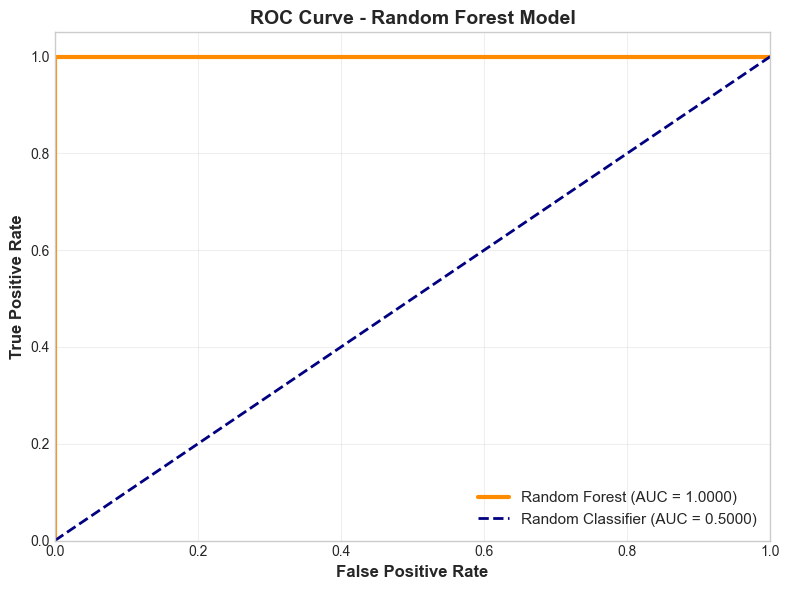

✓ ROC Curve plotted
  ROC-AUC Score: 1.0000


In [3]:
fig, ax = plt.subplots(figsize=(8, 6))

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_encoded, y_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
ax.plot(fpr, tpr, color='darkorange', lw=3, label=f'Random Forest (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier (AUC = 0.5000)')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('ROC Curve - Random Forest Model', fontsize=14, fontweight='bold')
ax.legend(loc="lower right", fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✓ ROC Curve plotted")
print(f"  ROC-AUC Score: {roc_auc:.4f}")

## 3. Confusion Matrix Heatmap

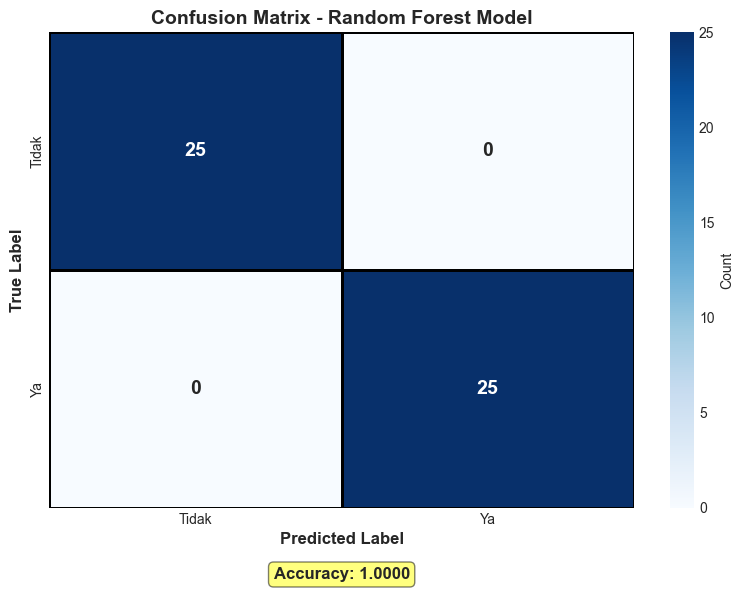

✓ Confusion Matrix visualized
  TN: 25, FP: 0
  FN: 0, TP: 25


In [4]:
cm = confusion_matrix(y_encoded, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Count'},
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            annot_kws={'size': 14, 'weight': 'bold'},
            ax=ax, linewidths=2, linecolor='black')

ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - Random Forest Model', fontsize=14, fontweight='bold')

# Add accuracy annotation
accuracy = accuracy_score(y_encoded, y_pred)
ax.text(0.5, -0.15, f'Accuracy: {accuracy:.4f}', transform=ax.transAxes, 
        ha='center', fontsize=12, fontweight='bold', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"✓ Confusion Matrix visualized")
print(f"  TN: {cm[0,0]}, FP: {cm[0,1]}")
print(f"  FN: {cm[1,0]}, TP: {cm[1,1]}")

## 4. Feature Importance

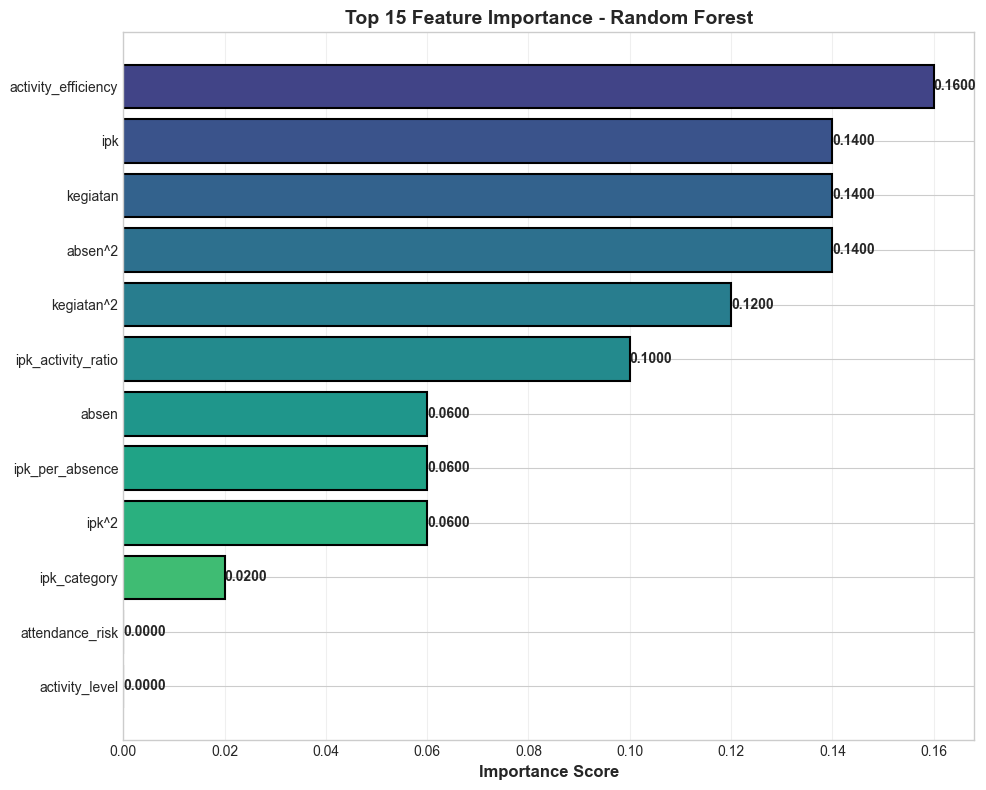

✓ Feature Importance visualized

Top 5 Important Features:
  activity_efficiency      : 0.1600
  ipk                      : 0.1400
  kegiatan                 : 0.1400
  absen^2                  : 0.1400
  kegiatan^2               : 0.1200


In [5]:
# Get feature importances
importances = model.feature_importances_
feature_names = X.columns

# Create dataframe and sort
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(feature_importance_df['Feature'], feature_importance_df['Importance'],
               color=plt.cm.viridis(np.linspace(0.2, 0.8, len(feature_importance_df))),
               edgecolor='black', linewidth=1.5)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, feature_importance_df['Importance'])):
    ax.text(val, bar.get_y() + bar.get_height()/2, f'{val:.4f}',
            ha='left', va='center', fontweight='bold', fontsize=10)

ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Feature Importance - Random Forest', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

print(f"✓ Feature Importance visualized")
print(f"\nTop 5 Important Features:")
for idx, row in feature_importance_df.head(5).iterrows():
    print(f"  {row['Feature']:25s}: {row['Importance']:.4f}")

## 5. Probability Distribution & Risk Stratification

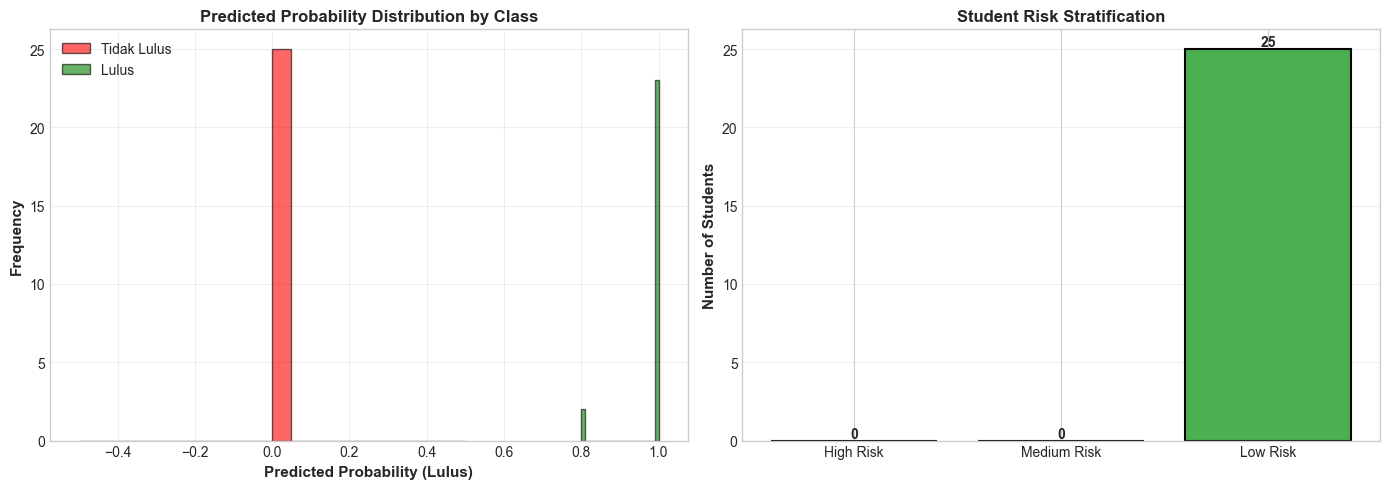

✓ Probability distribution and risk stratification visualized

Risk Stratification Summary:
  High Risk      :   0 students (  0.0%)
  Medium Risk    :   0 students (  0.0%)
  Low Risk       :  25 students ( 50.0%)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Probability distribution for each class
lulus_proba = y_proba[y_encoded == 1]
tidak_lulus_proba = y_proba[y_encoded == 0]

axes[0].hist(tidak_lulus_proba, bins=20, alpha=0.6, label='Tidak Lulus', color='red', edgecolor='black')
axes[0].hist(lulus_proba, bins=20, alpha=0.6, label='Lulus', color='green', edgecolor='black')
axes[0].set_xlabel('Predicted Probability (Lulus)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0].set_title('Predicted Probability Distribution by Class', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Plot 2: Risk stratification
risk_categories = pd.cut(y_proba, bins=[0, 0.3, 0.7, 1.0], labels=['High Risk', 'Medium Risk', 'Low Risk'])
risk_counts = risk_categories.value_counts().sort_index()

colors_risk = ['#FF6B6B', '#FFA500', '#4CAF50']
axes[1].bar(risk_counts.index, risk_counts.values, color=colors_risk, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Number of Students', fontsize=11, fontweight='bold')
axes[1].set_title('Student Risk Stratification', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

for bar in axes[1].patches:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"✓ Probability distribution and risk stratification visualized")
print(f"\nRisk Stratification Summary:")
for risk_cat in ['High Risk', 'Medium Risk', 'Low Risk']:
    count = (risk_categories == risk_cat).sum()
    pct = count / len(risk_categories) * 100
    print(f"  {risk_cat:15s}: {count:3d} students ({pct:5.1f}%)")